# Analysis of Natural Spatial Jitter in Skeleton Detection

This notebook focuses on the **spatial jitter** (natural noise) inherent in MediaPipe skeleton extraction. Jitter occurs due to micro-variations in landmark prediction across consecutive frames, even when the subject is relatively still. 

We use this analysis to justify the need for data augmentation (specifically Gaussian spatial jitter) to make the Sign Language Recognition model robust to such variances.

In [16]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# ===================================================
# GLOBAL CONFIGURATION — Academic Paper Style
# ===================================================
plt.style.use('default')
plt.rcParams.update({
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman'],
    'font.size'          : 9,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'figure.dpi'         : 300,
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
})

# Load Baseline Data
pickle_path = '../data/pickle/pose_bisindo.pkl'
with open(pickle_path, 'rb') as f:
    dataset = pickle.load(f)

SELECTED_ID = 'P01_S001_R01'
kp_data = dataset[SELECTED_ID]['keypoints'] # (T, K, 2)
T, K, _ = kp_data.shape

print(f"Loaded video: {SELECTED_ID} ({T} frames)")

Loaded video: P01_S001_R01 (185 frames)


## 1. 2D Sequence: Hand Keypoints

This visualization shows the skeletal structure across consecutive frames. We highlight points that exhibit the most significant temporal shift to demonstrate jitter progression.

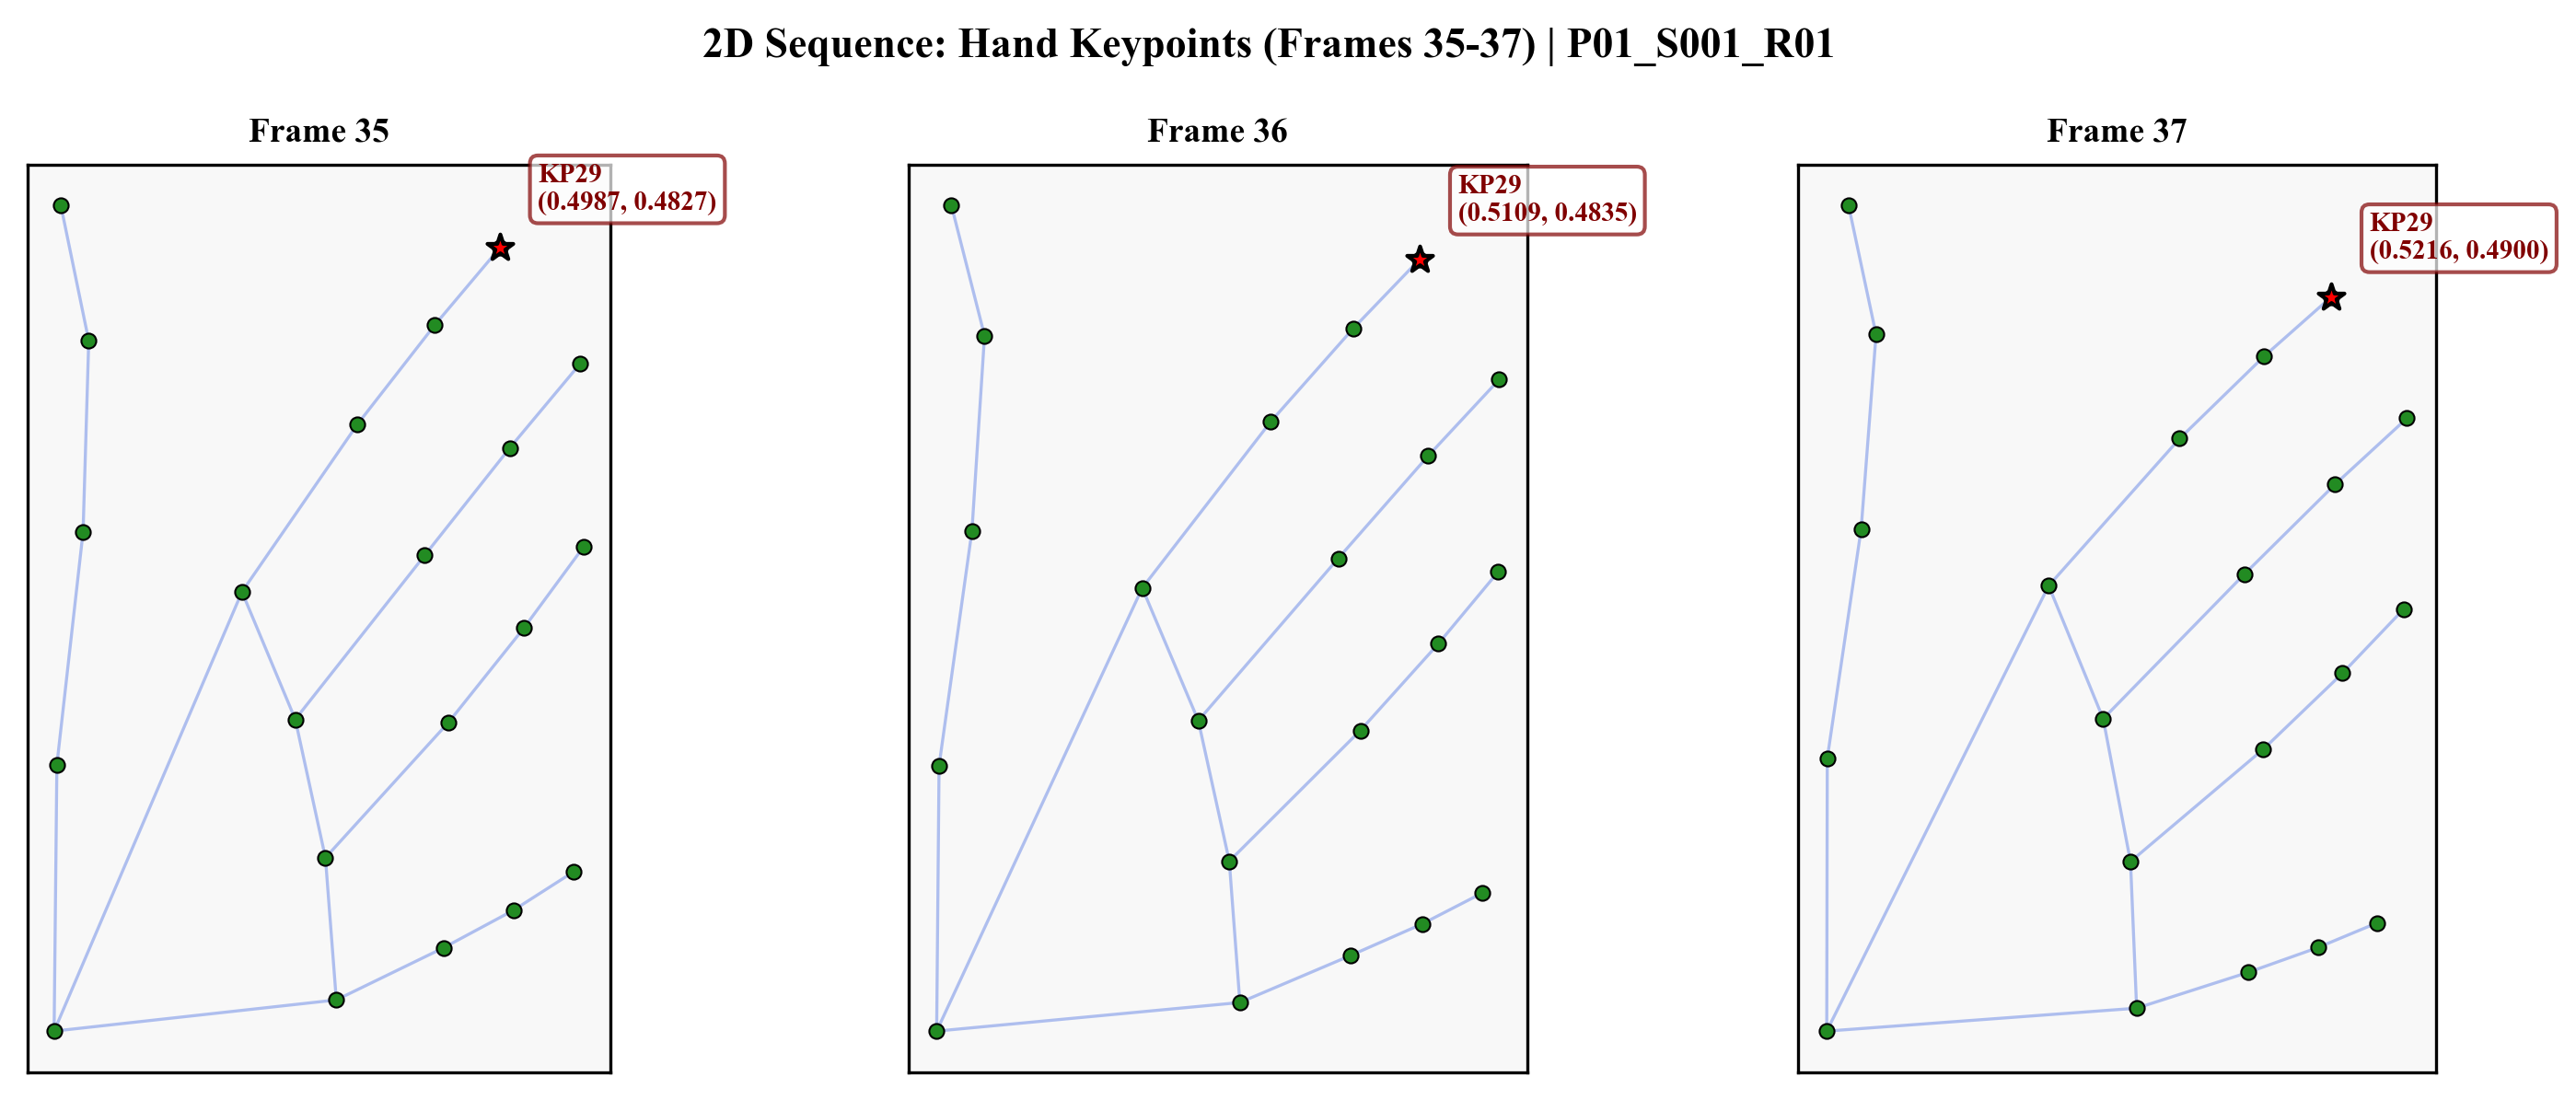

In [17]:
def get_hand_conns():
    # Connections for hand (0-20 left, 21-41 right)
    connections = [
        (0,1), (1,2), (2,3), (3,4), (0,5), (5,6), (6,7), (7,8), 
        (5,9), (9,10), (10,11), (11,12), (9,13), (13,14), (14,15), (15,16),
        (13,17), (17,18), (18,19), (19,20), (0,17)
    ]
    return connections + [(p1+21, p2+21) for p1, p2 in connections]

def plot_hand_skeleton(ax, points, title, highlight_idx=None, highlight_text=None):
    all_conns = get_hand_conns()
    
    # Plot connections
    for p1, p2 in all_conns:
        if points[p1,0] != 0 and points[p2,0] != 0:
            ax.plot([points[p1,0], points[p2,0]], [points[p1,1], points[p2,1]], 
                    color='#4169E1', alpha=0.4, linewidth=0.8, zorder=1)
            
    # Plot joints
    valid_mask = points[:42, 0] != 0
    ax.scatter(points[:42][valid_mask, 0], points[:42][valid_mask, 1], 
               c='#228B22', s=15, edgecolors='black', linewidths=0.5, zorder=2)
    
    # Highlight specific point
    if highlight_idx is not None and points[highlight_idx, 0] != 0:
        px, py = points[highlight_idx]
        ax.scatter(px, py, c='red', marker='*', s=50, edgecolors='black', zorder=4, label='Shifted Joint')
        if highlight_text:
            ax.annotate(f"KP{highlight_idx}\n({px:.4f}, {py:.4f})", (px, py), 
                        xytext=(10, 10), textcoords='offset points', 
                        fontsize=7, fontweight='bold', color='maroon',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='maroon', alpha=0.7))
    
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('#F8F8F8')

start_f = 35
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, f_idx in enumerate([start_f, start_f+1, start_f+2]):
    # Track Index Finger Tip (KP 8 or 29)
    plot_hand_skeleton(axes[i], kp_data[f_idx], f"Frame {f_idx}", highlight_idx=29, highlight_text=True)

plt.suptitle(f"2D Sequence: Hand Keypoints (Frames {start_f}-{start_f+2}) | {SELECTED_ID}", 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. 2D Comparison: Original vs Jittered

This side-by-side view compares stable detection with an augmented version using **Gaussian Spatial Jitter**. We mark a specific landmark to visualize the exact coordinate shift caused by the perturbation.

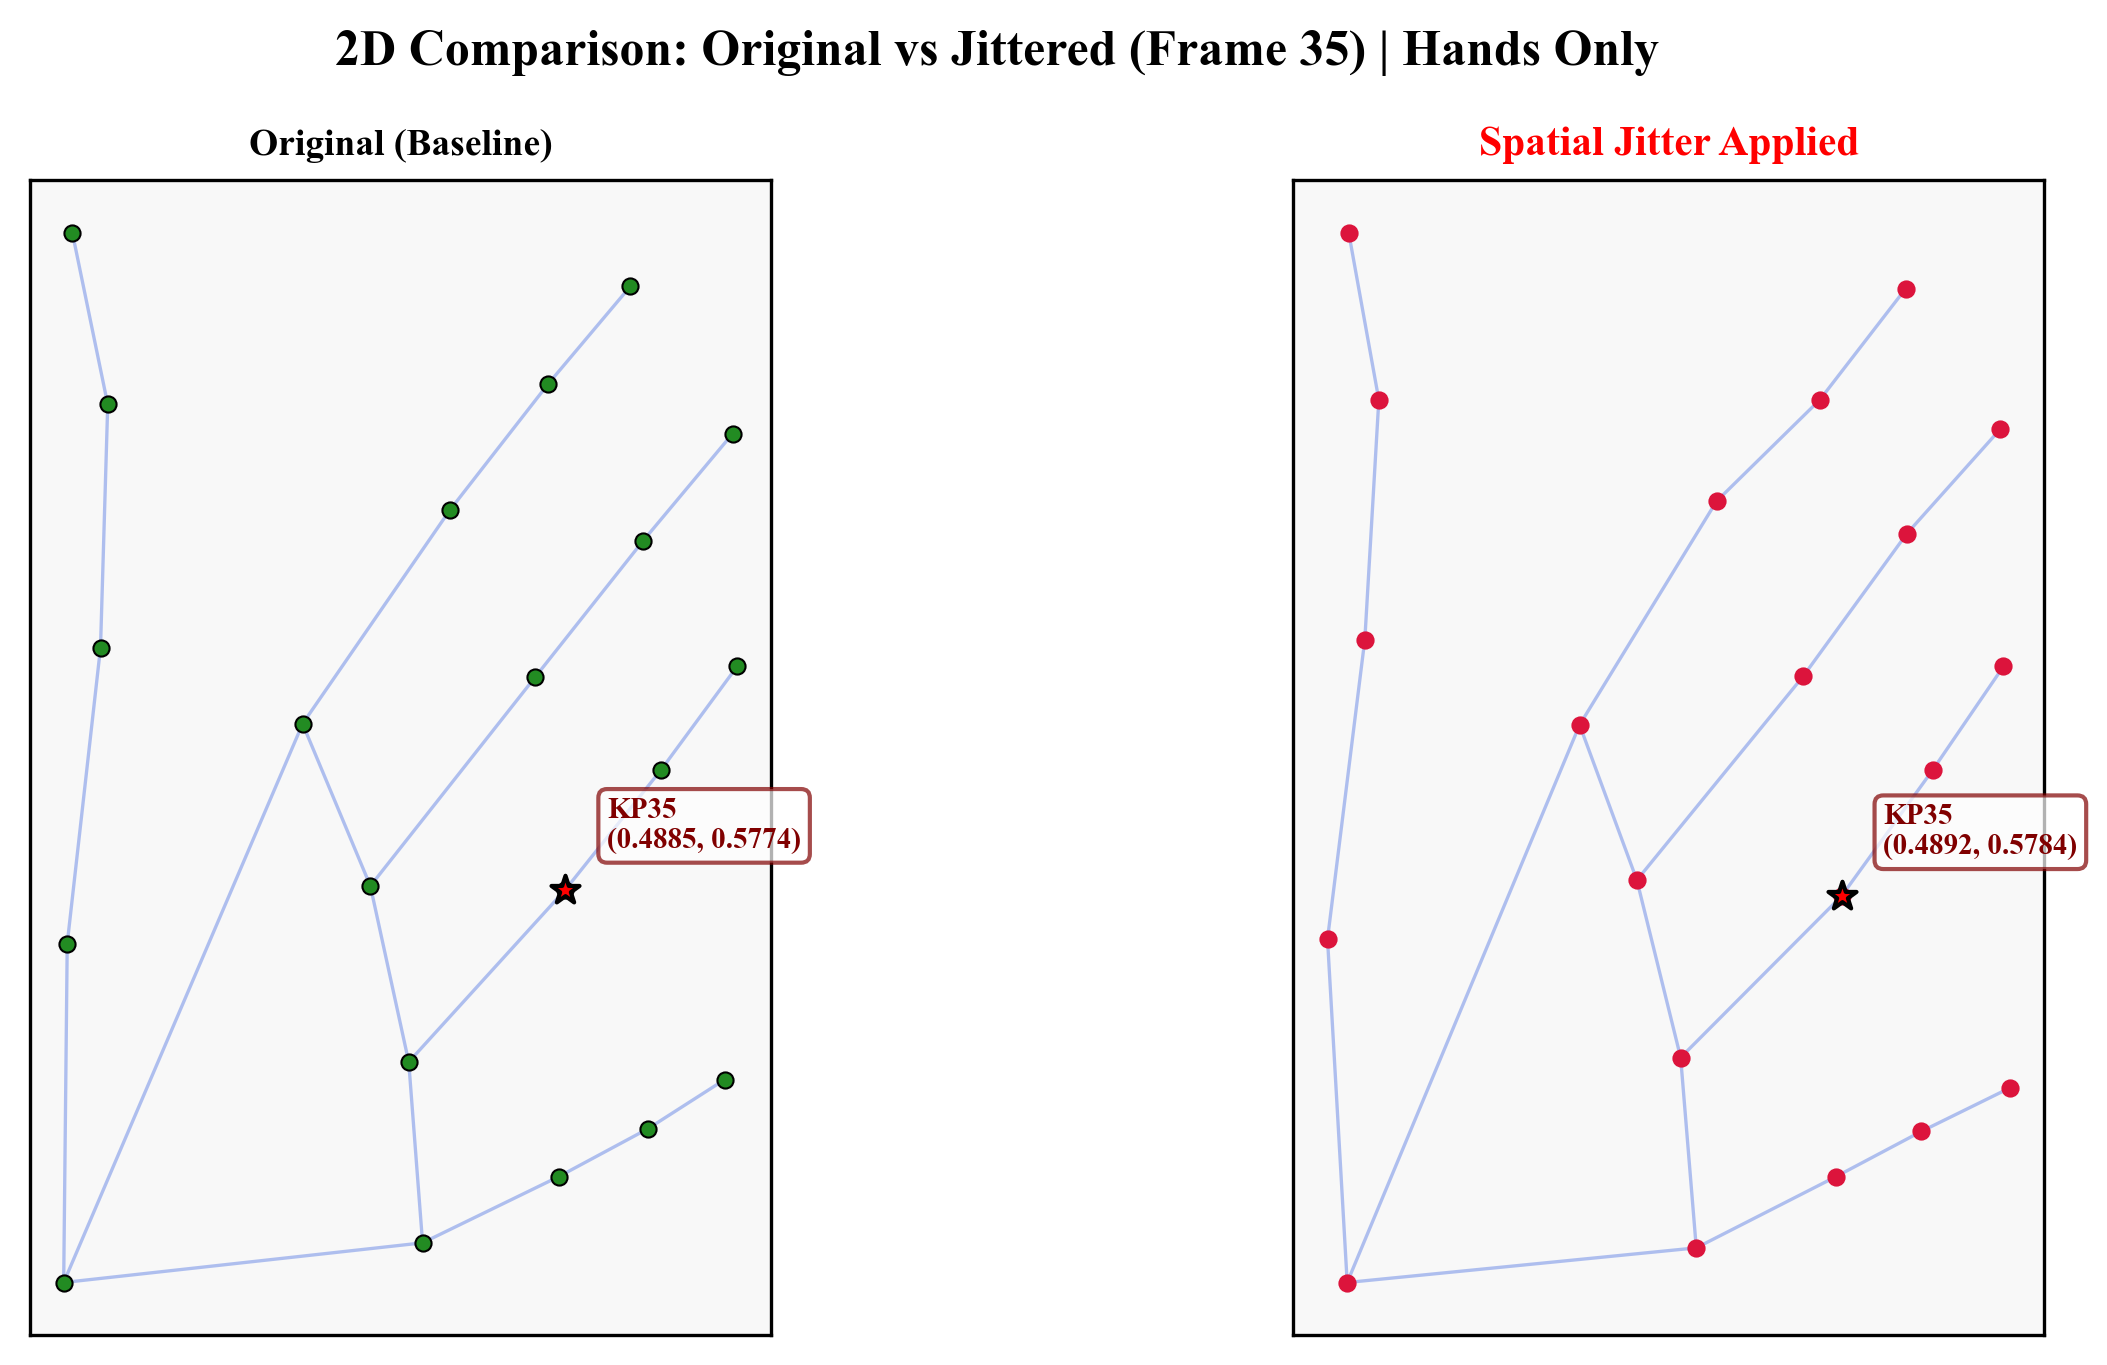

In [20]:
def apply_jitter(points, std_dev=0.005):
    noise = np.random.normal(0, std_dev, points.shape)
    mask = (points != 0)
    jittered = points.copy()
    jittered[mask] += noise[mask]
    return jittered

target_frame = 35
orig = kp_data[target_frame]
jittered = apply_jitter(orig, std_dev=0.001)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

test_kp = 35 # Pinky tip
plot_hand_skeleton(ax1, orig, "Original (Baseline)", highlight_idx=test_kp, highlight_text=True)
plot_hand_skeleton(ax2, jittered, "Spatial Jittered (+ Augmentation)", highlight_idx=test_kp, highlight_text=True)

# Styling ax2 specifically to show the difference label
ax2.collections[0].set_color('#DC143C') # Change point colors for jittered view
ax2.set_title("Spatial Jitter Applied", color='red')

plt.suptitle(f"2D Comparison: Original vs Jittered (Frame {target_frame}) | Hands Only", 
             fontsize=12, fontweight='bold')
plt.show()

## 3. Spatial Jitter Comparison: std_dev ($ \sigma $)

Evaluating the variance impact of different standard deviation values. A larger $ \sigma $ simulates harsher environmental noise or faster movement blur.

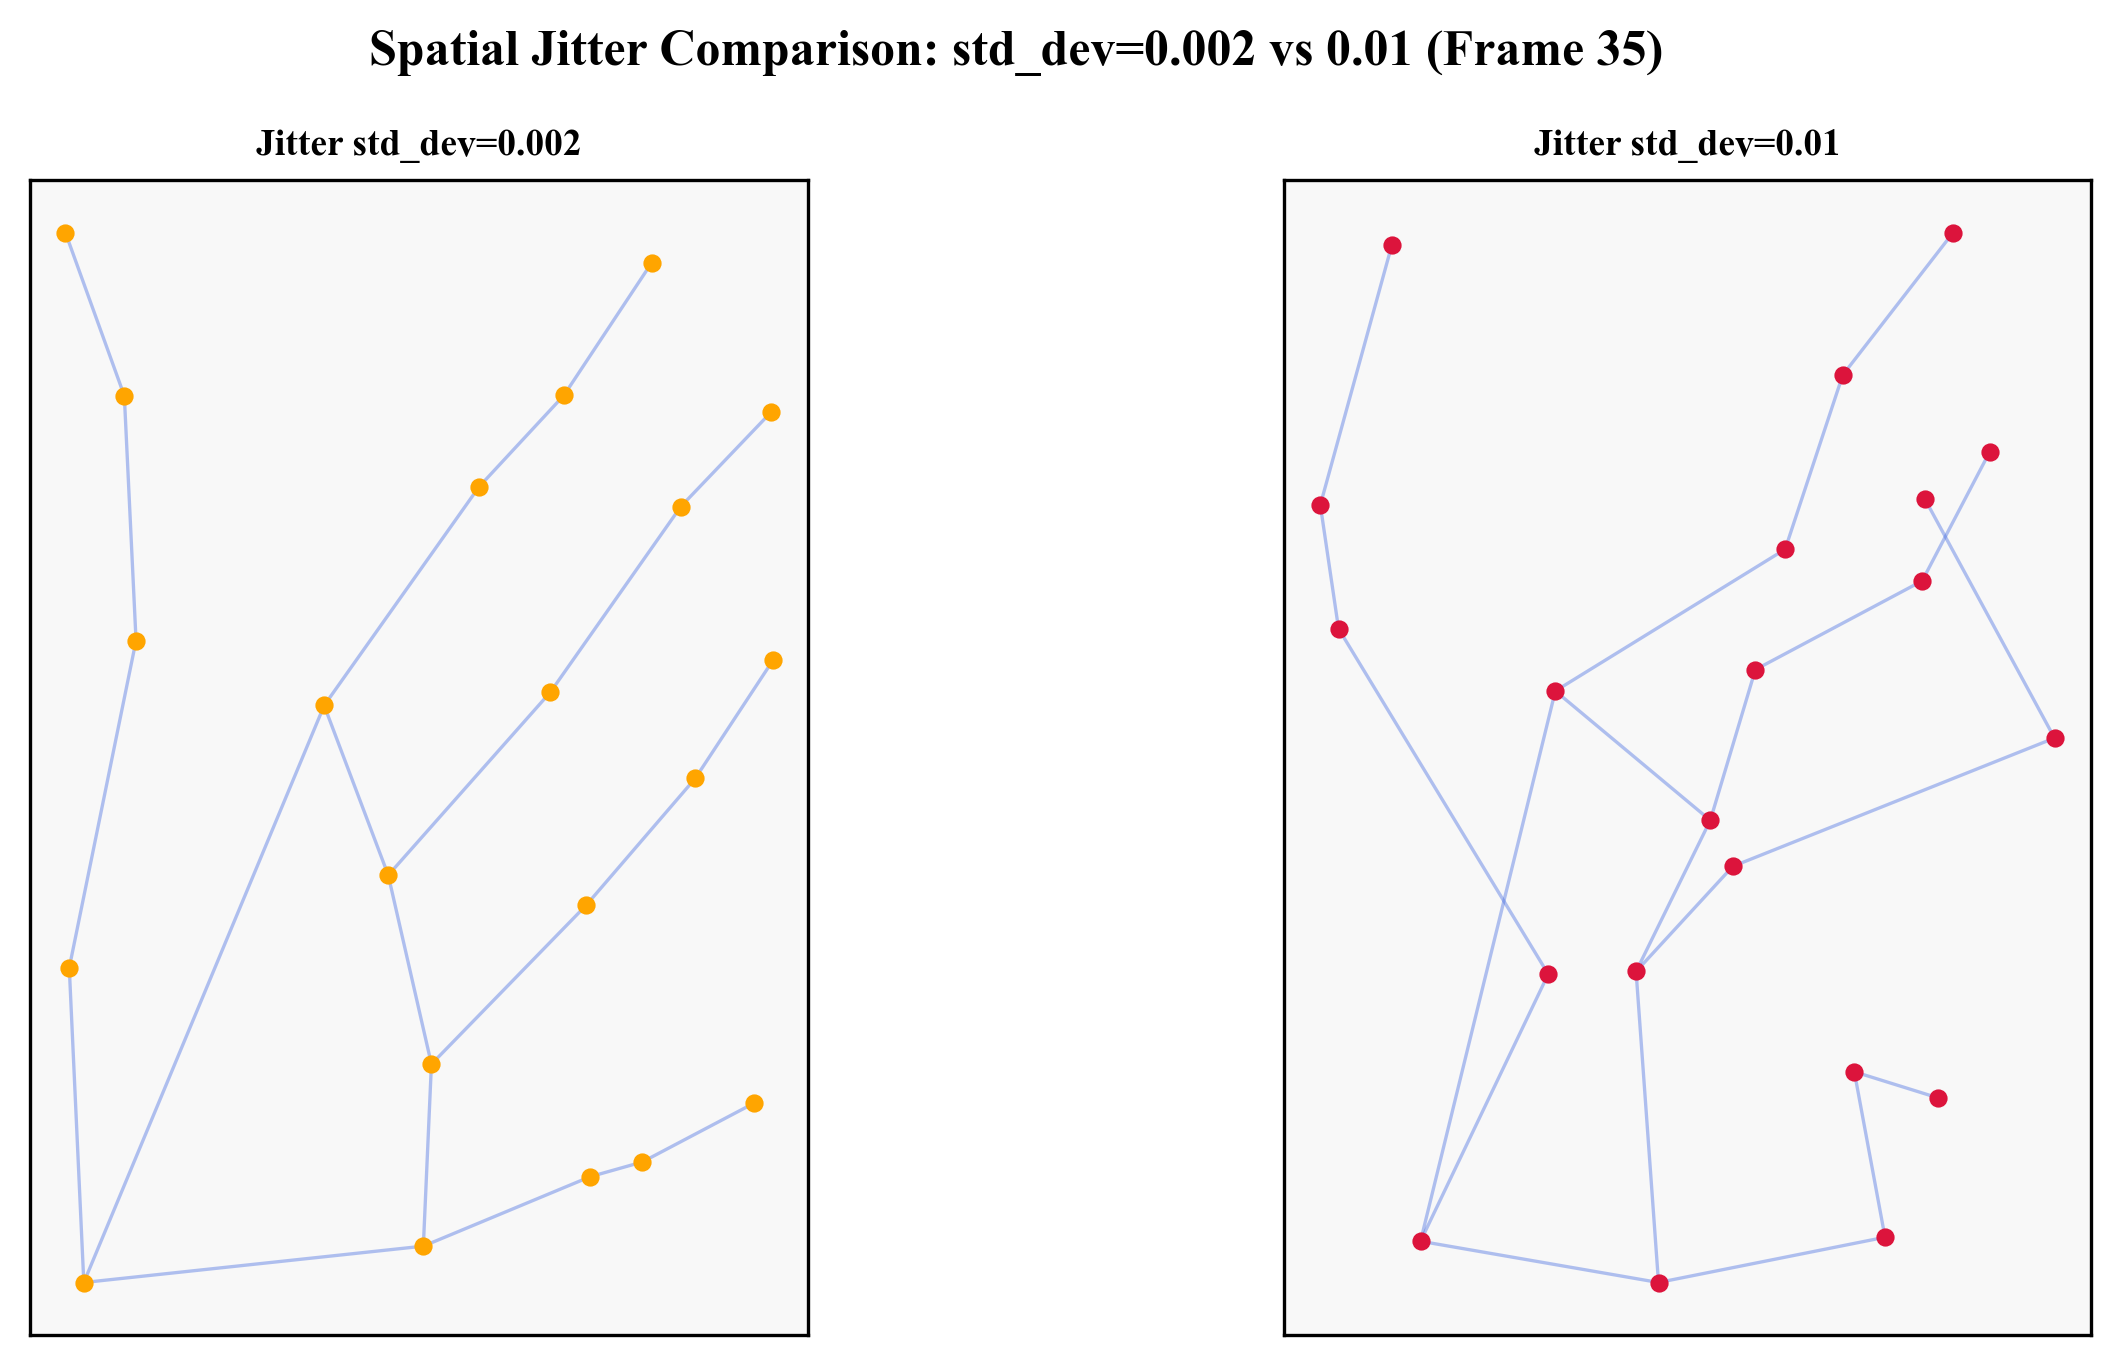

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

j1 = apply_jitter(orig, std_dev=0.002)
j2 = apply_jitter(orig, std_dev=0.01)

plot_hand_skeleton(ax1, j1, "Jitter std_dev=0.002")
ax1.collections[0].set_color('orange')

plot_hand_skeleton(ax2, j2, "Jitter std_dev=0.01")
ax2.collections[0].set_color('crimson')

plt.suptitle(f"Spatial Jitter Comparison: std_dev=0.002 vs 0.01 (Frame {target_frame})", 
             fontsize=12, fontweight='bold')
plt.show()